In [3]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

In [4]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *

import numpy as np
import matplotlib.pyplot as plt

In [5]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [6]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05

In [7]:
r_pupil = f * num_apt
r_bfp = L_bfp / 2
na_eff = num_apt
#effective NA can be limited by the size of the back focal plane
if r_bfp < r_pupil:
    na_eff = r_bfp / f
alpha = np.arcsin(na_eff / n)

R_BFP = r_bfp

microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, grid_size)
L_ffp = 0.0065
grid_ffp = 256
z_level = 0.01
grid = Centered_Square_Grid(L_ffp, grid_ffp, z_level)
aberration = Aberration([[0, 4]], [0.5])

In [ ]:
import time

grid_ffps = np.array([4, 8, 16, 32, 64, 128, 256, 512, 1024])
slow_times = np.zeros(len(grid_ffps))
fast_times = np.zeros(len(grid_ffps))

for i, grid_ffp  in enumerate(grid_ffps):
    grid = Centered_Square_Grid(L_ffp, grid_ffp, z_level)
    s = time.time()
    x, y, I = microscope.old_compute_PSF(grid, aberration)
    t = time.time()

    slow_times[i] = t - s

    s = time.time()
    x, y, I = microscope.compute_PSF(grid, aberration)
    t = time.time()

    fast_times[i] = t - s

    print(f"Done with {grid_ffp}")


Done with 4
Done with 8
Done with 16
Done with 32
Done with 64
Done with 128


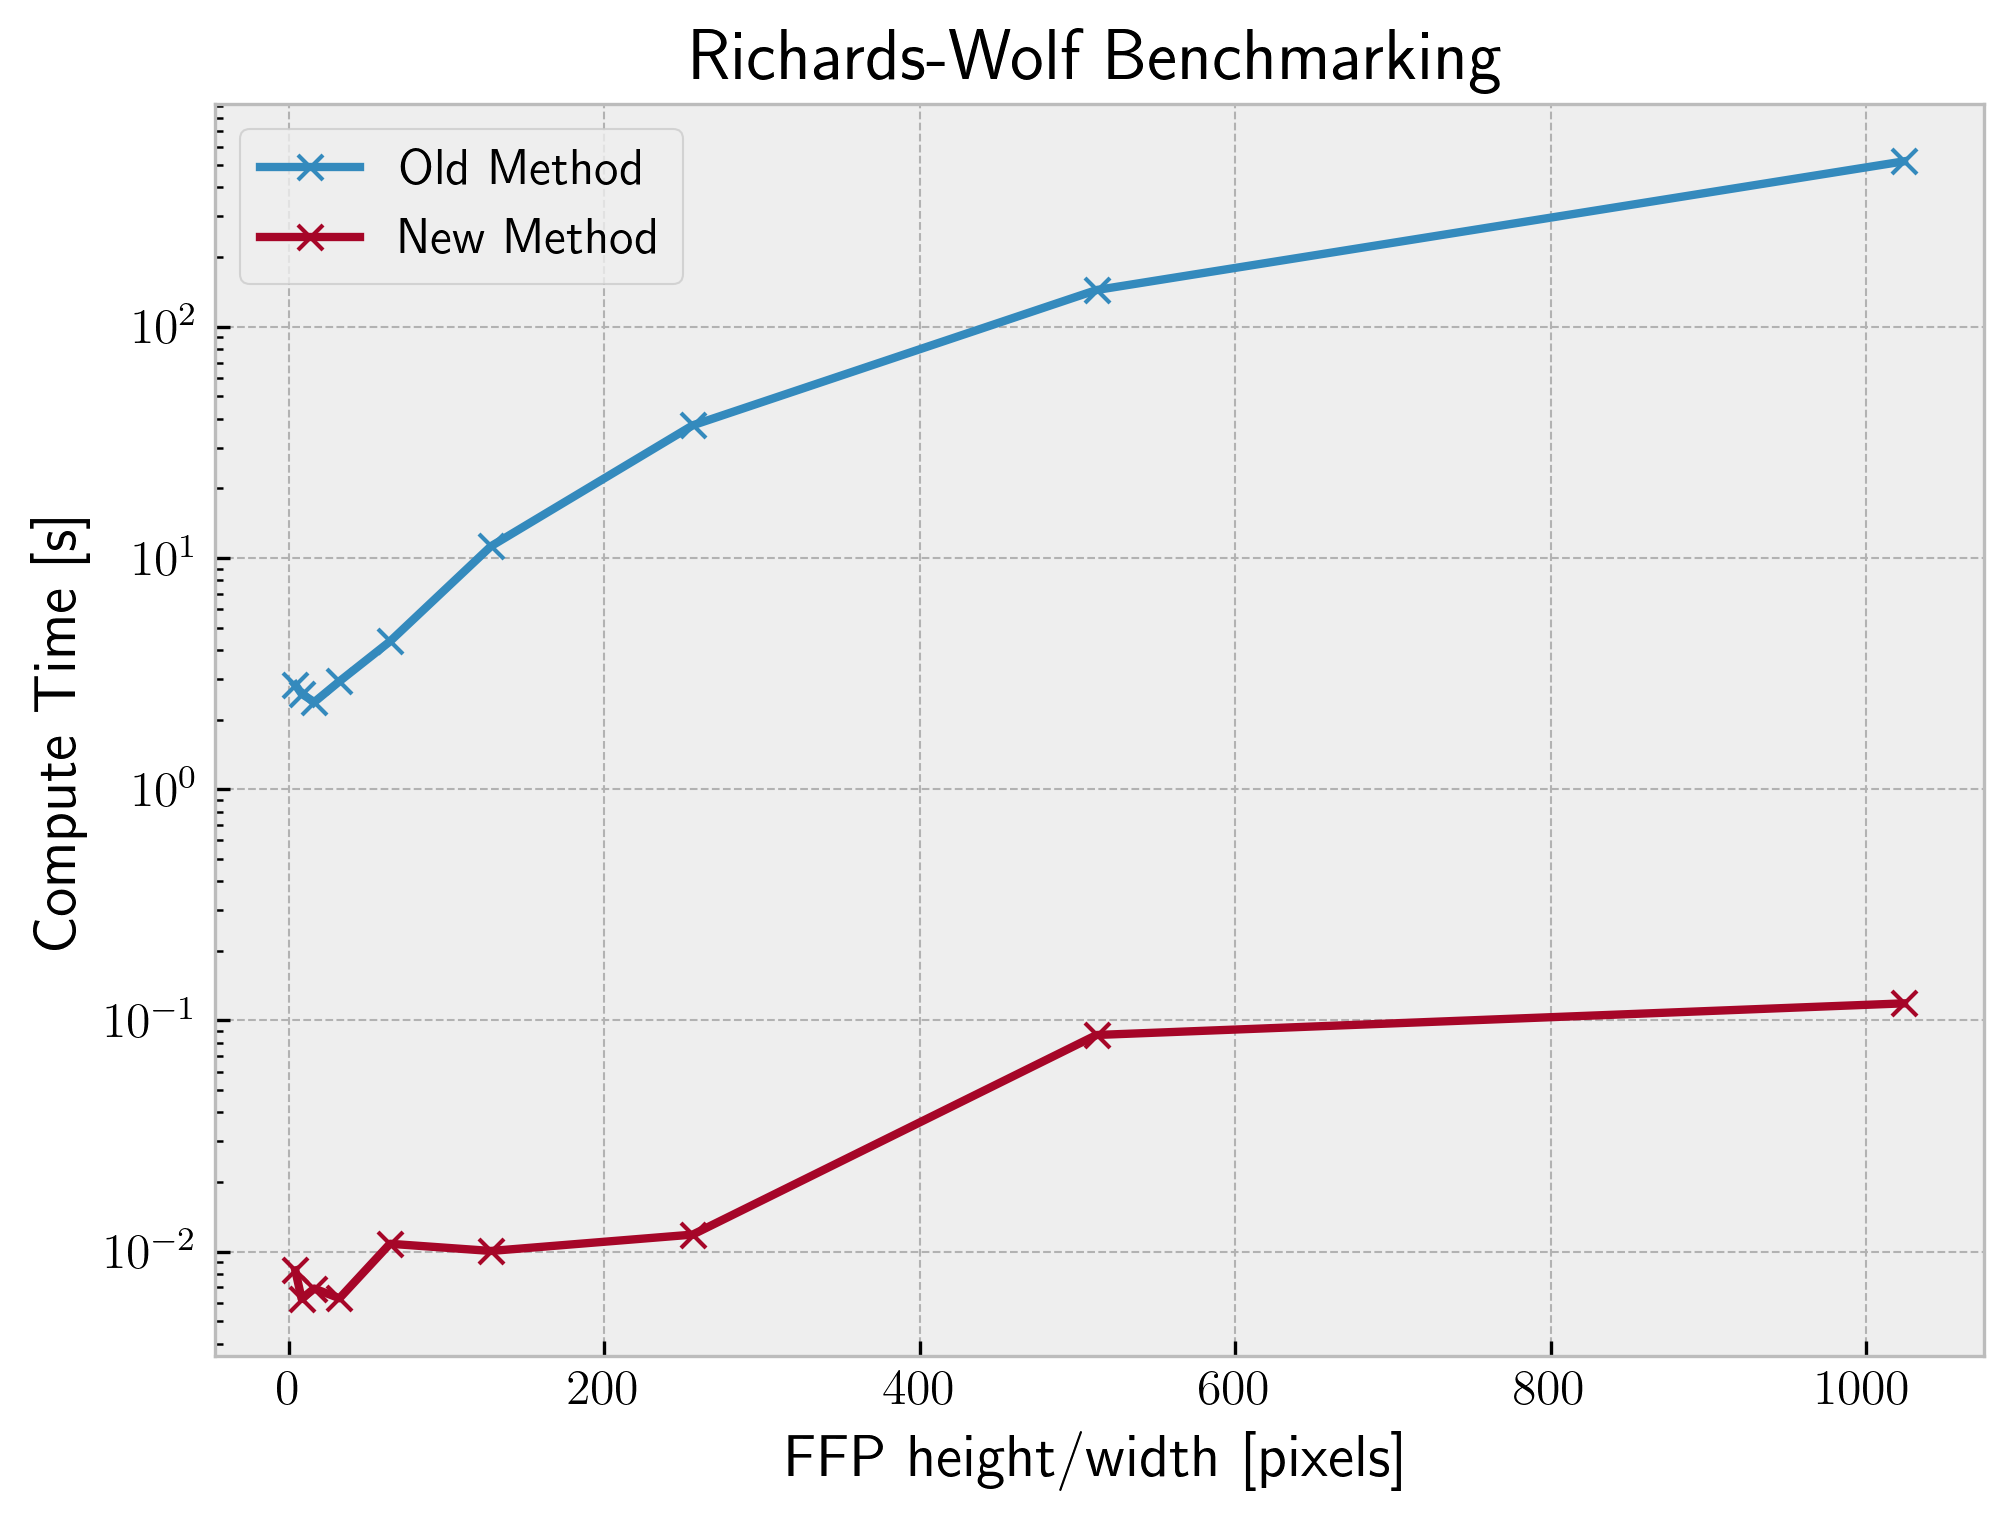

In [ ]:
fig, ax = plt.subplots()
ax.set_title("Richards-Wolf Benchmarking")
ax.plot(grid_ffps, slow_times, label = "Old Method", marker = "x")
ax.plot(grid_ffps, fast_times, label = "New Method", marker = "x")
ax.set_ylabel("Compute Time [s]")
ax.set_xlabel("FFP height/width [pixels]")
ax.legend()
ax.set_yscale("log")
plt.savefig("speed_benchmark.png")

In [65]:
L_ffp = 0.01
grid_ffp = 128

frames =[microscope.compute_PSF(Centered_Square_Grid(L_ffp, grid_ffp, z_level), aberration)[2]
         for z_level in np.arange(0, 0.1, 0.0001)]

In [66]:
def arrays_to_gif(arrays, filename="out.gif", duration=100):
    frames = []

    for arr in arrays:
        arr = np.asarray(arr)

        # Normalize to 0–255 if not already uint8
        if arr.dtype != np.uint8:
            arr = arr.astype(float)
            arr = arr - np.nanmin(arr)
            arr = arr / np.nanmax(arr)
            arr = (255 * arr).astype(np.uint8)

        frames.append(Image.fromarray(arr))

    frames[0].save(
        filename,
        save_all=True,
        append_images=frames[1:],
        duration=duration,  # ms per frame
        loop=0
    )

In [67]:
arrays_to_gif(frames, "demo.gif")